In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei']

为啥工作表一找不到呢

In [2]:
participation_df = pd.read_excel("数据集.xlsx", index_col= 0, sheet_name = 'Sheet1')

ValueError: Worksheet named 'Sheet1' not found

In [242]:
participation_df = pd.read_excel("数据集.xlsx", index_col= 0, sheet_name = 'Sheet1')
time_df = pd.read_excel("./data1_hw.xlsx", index_col= 0, sheet_name = 'Sheet2',
                     usecols = "A:F", nrows = 1)
frequency_df = pd.read_excel("./data1_hw.xlsx", index_col= 0, sheet_name = 'Sheet2',
                             usecols = "A:F", skiprows = 2, nrows = 1)
way_df = pd.read_excel("./data1_hw.xlsx", index_col= 0, sheet_name = 'Sheet2',
                      usecols = 'A:D', skiprows = 4, nrows = 1)
way_df

,个人自发参与,公司或单位组织,社区居委会组织
3,,,
参与冰雪运动的方式,0.9264,0.1226,0.0397


In [235]:
# df = pd.DataFrame(participation_df.loc["参与率"])
# df
participation_df = participation_df.drop(['参与人数'])
participation_df*100

,18及以上,18以下,全国参与率,成年人比未成年人多,18-30,60以上,城镇,农村,北方,南方,男,女
,,,,,,,,,,,,
参与率,26.95,15.62,24.56,11.33,37.27,13.09,29.93,15.08,32.43,19.19,22.1,24.23


这里为什么写全国参与率就不行了

In [182]:
df1 = pd.DataFrame(participation_df, columns = ['18及以上','18以下', '全国参与率'])
df1.loc['参与率'].apply(lambda x: format(x, '.2%'))
df2 = pd.DataFrame(participation_df, columns = ['城镇','农村'])
df2.loc['参与率'].apply(lambda x: format(x, '.2%'))
df3 = pd.DataFrame(participation_df, columns= ['北方','南方'])
df3.loc['参与率'].apply(lambda x: format(x, '.2%'))
df4 = pd.DataFrame(participation_df, columns= ['男', '女'])
df4.loc['参与率'].apply(lambda x: format(x, '.2%'))

男    22.10%
女    24.23%
Name: 参与率, dtype: object

In [249]:
from statsmodels.graphics.mosaicplot import mosaic

In [254]:
df3

,北方,南方
,,
参与率,0.3243,0.1919


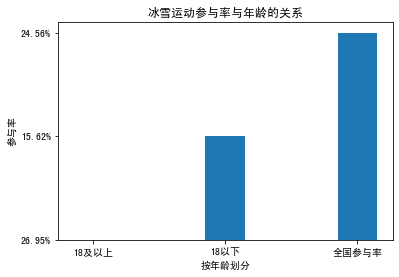

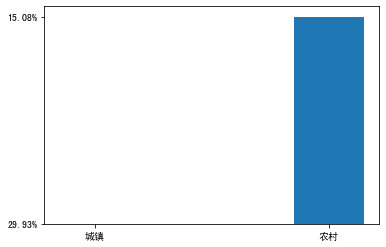

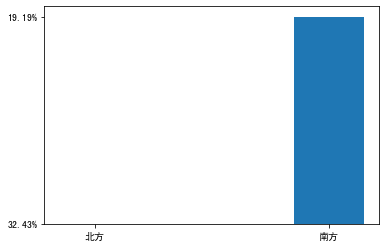

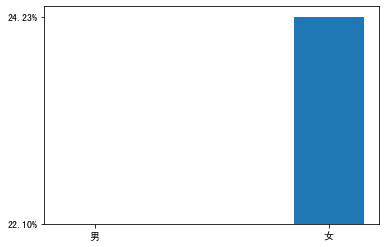

In [180]:
ax1 = plt.figure()
# ax1 = fig.add_subplot(2, 2, 1)
ax1= plt.bar(['18及以上','18以下', '全国参与率'],df1.loc['参与率'].apply(lambda x: format(x, '.2%')), width = 0.3, data = df1)
ax1.set_label('年龄与参与率')
plt.xlabel("按年龄划分")
plt.ylabel("参与率")
plt.title("冰雪运动参与率与年龄的关系")
# ax2 = fig.add_subplot(2, 2, 2)
ax2 = plt.figure()
ax2 = plt.bar(['城镇','农村'],df2.loc['参与率'].apply(lambda x: format(x, '.2%')), width = 0.3, data = df1)
# ax3 = fig.add_subplot(2, 2, 3)
ax3 = plt.figure()
ax3 = plt.bar(['北方','南方'],df3.loc['参与率'].apply(lambda x: format(x, '.2%')), width = 0.3, data = df1)
#  ax4 = fig.add_subplot(2, 2, 4)
ax4 = plt.figure()
ax4 = plt.bar(['男', '女'],df4.loc['参与率'].apply(lambda x: format(x, '.2%')), width = 0.3, data = df1)
plt.show()

In [258]:
time_df.loc['最近一次参与冰雪运动的时间']

半年以内     0.0705
半年~一年    0.3496
一年~两年    0.1815
两年~三年    0.0984
三年前      0.3000
Name: 最近一次参与冰雪运动的时间, dtype: float64

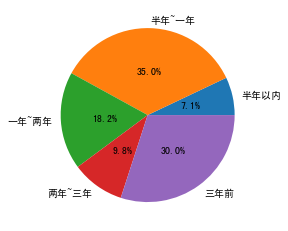

In [237]:
plt.pie(time_df.loc['最近一次参与冰雪运动的时间'], 
        labels = time_df.loc['最近一次参与冰雪运动的时间'].index,
       autopct='%1.1f%%', pctdistance=0.5)
plt.show()

In [245]:
way_df.iloc[:, 0:3]

,个人自发参与,公司或单位组织,社区居委会组织
3,,,
参与冰雪运动的方式,0.9264,0.1226,0.0397


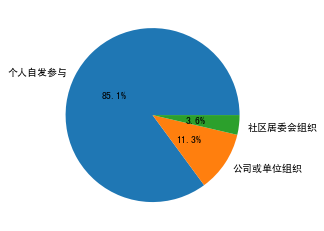

In [247]:
plt.pie(way_df.loc['参与冰雪运动的方式'], 
        labels = way_df.loc['参与冰雪运动的方式'].index,
       autopct='%1.1f%%', pctdistance=0.5)
plt.show()

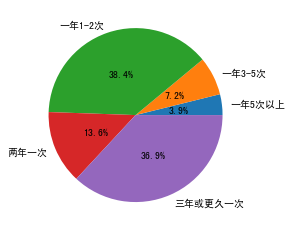

In [257]:
plt.pie(frequency_df.loc['参与冰雪运动的频率'], 
        labels = frequency_df.loc['参与冰雪运动的频率'].index,
       autopct='%1.1f%%', pctdistance=0.5)
plt.show()

In [256]:
frequency_df

,一年5次以上,一年3-5次,一年1-2次,两年一次,三年或更久一次
2,,,,,
参与冰雪运动的频率,0.0386,0.0716,0.3843,0.1363,0.3692


绘制马赛克图-卡方检验

In [259]:
df5 = pd.read_excel("./data1_hw.xlsx", index_col= 0, sheet_name = 'Sheet3',
                     usecols = "D:F", nrows = 2)

In [260]:
df5

,南方.1,北方.1
室内冰雪运动参与率,2.566440,1.012872
室外冰雪运动参与率,2.720812,1.100623


(<Figure size 432x288 with 3 Axes>,
 {('2.56643982', '1.0128716400000002'): (0.0,
   0.0,
   0.49751243781094534,
   0.9966777408637874),
  ('2.56643982', '1.1006232599999999'): (0.0, 1.0, 0.49751243781094534, 0.0),
  ('2.7208121399999996', '1.0128716400000002'): (0.5024875621890548,
   0.0,
   0.49751243781094534,
   0.0),
  ('2.7208121399999996', '1.1006232599999999'): (0.5024875621890548,
   0.0033222591362126247,
   0.49751243781094534,
   0.9966777408637874)})

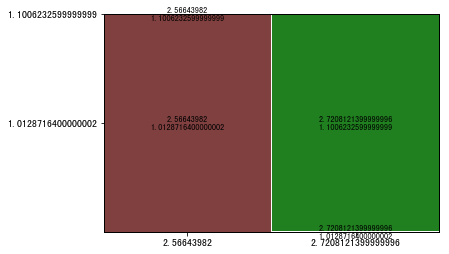

In [261]:
mosaic(df5, ['南方.1', '北方.1'])